<a href="https://colab.research.google.com/github/ummasalmaj2004-netizen/camera/blob/main/clus_DMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


In [9]:
from google.colab import files
uploaded = files.upload()

# Load dataset
data = pd.read_csv("Mall_Customers.csv")
print(data.head())
print(data.info())
print(data.columns)


Saving Mall_Customers.csv to Mall_Customers (2).csv
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

In [10]:
# Encode 'Genre' (Male=0, Female=1)
data['Genre'] = data['Genre'].map({'Male':0, 'Female':1})

# Select features
X = data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Genre']]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


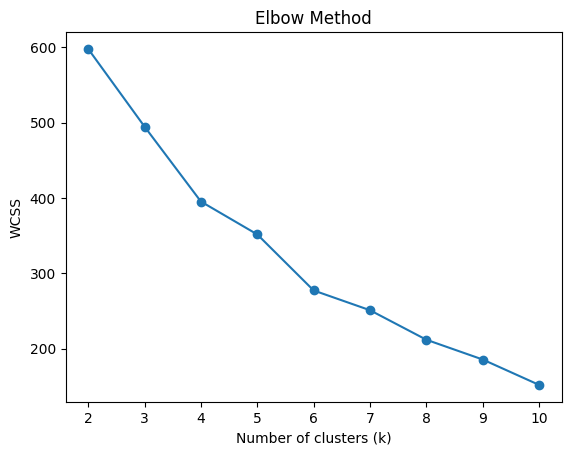

In [11]:
wcss = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(2, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS")
plt.show()


In [12]:
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, silhouette score={score:.3f}")


k=2, silhouette score=0.278
k=3, silhouette score=0.258
k=4, silhouette score=0.290
k=5, silhouette score=0.272
k=6, silhouette score=0.335


In [13]:
# Example: k=4 chosen
kmeans = KMeans(n_clusters=4, random_state=42)
data['Cluster'] = kmeans.fit_predict(X_scaled)


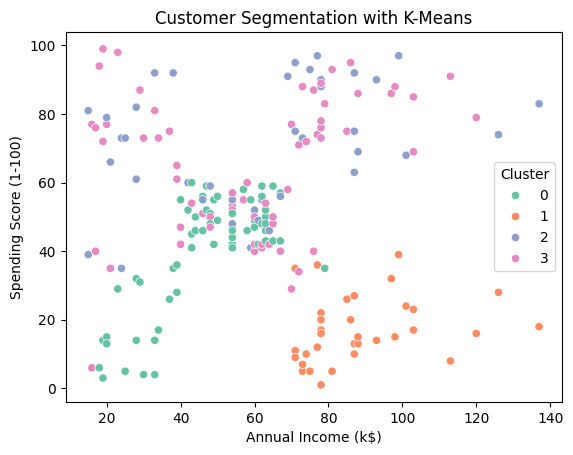

In [14]:
sns.scatterplot(x=data['Annual Income (k$)'],
                y=data['Spending Score (1-100)'],
                hue=data['Cluster'], palette='Set2')
plt.title("Customer Segmentation with K-Means")
plt.show()


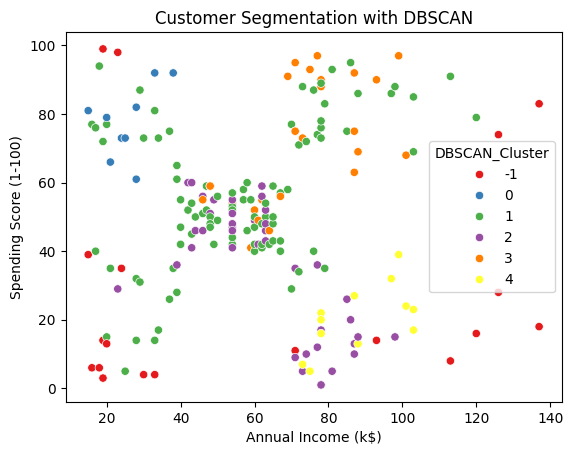

DBSCAN cluster labels: [-1  0  1  2  3  4]


In [16]:
from sklearn.cluster import DBSCAN

# Apply DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=5)  # adjust eps for density sensitivity
labels = dbscan.fit_predict(X_scaled)

# Add cluster labels
data['DBSCAN_Cluster'] = labels

# Visualize DBSCAN clusters
sns.scatterplot(x=data['Annual Income (k$)'],
                y=data['Spending Score (1-100)'],
                hue=data['DBSCAN_Cluster'], palette='Set1')
plt.title("Customer Segmentation with DBSCAN")
plt.show()

# Count clusters and noise (-1 = noise)
print("DBSCAN cluster labels:", np.unique(labels))


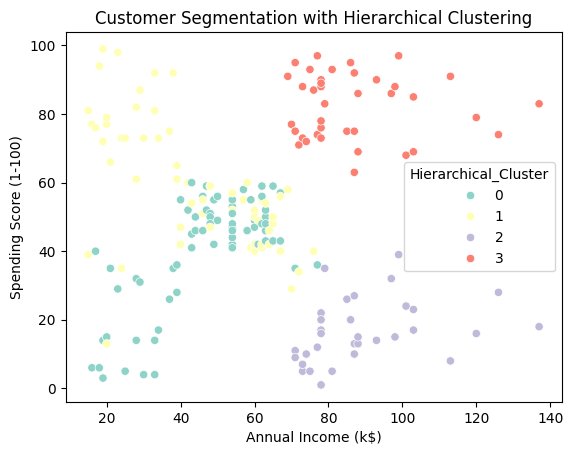

In [17]:
from sklearn.cluster import AgglomerativeClustering

# Apply Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels = agg.fit_predict(X_scaled)

# Add cluster labels
data['Hierarchical_Cluster'] = labels

# Visualize Hierarchical clusters
sns.scatterplot(x=data['Annual Income (k$)'],
                y=data['Spending Score (1-100)'],
                hue=data['Hierarchical_Cluster'], palette='Set3')
plt.title("Customer Segmentation with Hierarchical Clustering")
plt.show()


In [18]:
print(data.groupby('Cluster').mean())


         CustomerID     Genre        Age  Annual Income (k$)  \
Cluster                                                        
0         67.783333  0.566667  54.700000           46.900000   
1        164.529412  0.411765  41.264706           88.500000   
2        100.809524  0.000000  28.690476           60.904762   
3         96.953125  1.000000  29.375000           58.296875   

         Spending Score (1-100)  DBSCAN_Cluster  Hierarchical_Cluster  
Cluster                                                                
0                     39.933333        1.150000              0.050000  
1                     16.764706        2.176471              1.882353  
2                     70.238095        1.904762              1.809524  
3                     64.437500        0.906250              1.578125  


In [19]:
print("K-Means clusters:", data['Cluster'].unique())
print("DBSCAN clusters:", np.unique(data['DBSCAN_Cluster']))
print("Hierarchical clusters:", np.unique(data['Hierarchical_Cluster']))

# Quick summary of average values per cluster (K-Means vs DBSCAN vs Hierarchical)
print("\nK-Means Cluster Summary:")
print(data.groupby('Cluster').mean())

print("\nDBSCAN Cluster Summary:")
print(data.groupby('DBSCAN_Cluster').mean())

print("\nHierarchical Cluster Summary:")
print(data.groupby('Hierarchical_Cluster').mean())


K-Means clusters: [2 3 0 1]
DBSCAN clusters: [-1  0  1  2  3  4]
Hierarchical clusters: [0 1 2 3]

K-Means Cluster Summary:
         CustomerID     Genre        Age  Annual Income (k$)  \
Cluster                                                        
0         67.783333  0.566667  54.700000           46.900000   
1        164.529412  0.411765  41.264706           88.500000   
2        100.809524  0.000000  28.690476           60.904762   
3         96.953125  1.000000  29.375000           58.296875   

         Spending Score (1-100)  DBSCAN_Cluster  Hierarchical_Cluster  
Cluster                                                                
0                     39.933333        1.150000              0.050000  
1                     16.764706        2.176471              1.882353  
2                     70.238095        1.904762              1.809524  
3                     64.437500        0.906250              1.578125  

DBSCAN Cluster Summary:
                CustomerID     Gen